# 3. Trend analysis observations Notebook
## 3a. Probabilistic method

---

## How to Use This Notebook

**1. Follow the numbered steps in order.**  
Each section builds upon the previous one, from setup, data loading, and climatology computation, to event analysis and visualization.

**2. Look for <font color="orange"> Orange cells  </font> and code cells marked as <font color="lightgreen">##### (User selection) ##### </font>:** 
| <font color="orange"> Orange cells  </font> | <font color="orange"> Need user intervantion </font>|
| ----------- | ----------- |
| <font color="green">**Green cells** </font> | <font color="green">**Run automatically on user input provided in the orange cells and should not be adjusted in most cases** </font>|


**3. Run cells sequentially.**  
Start from the top and execute each cell (`Shift` + `Enter`).  

### <font color="green"> Import require packages </font>

In [1]:
from c3s_lib import *
import xarray as xr
import pandas as pd
import os
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
# import R libraries from WWA
ro.r('''if (!requireNamespace("devtools", quietly = TRUE)) {install.packages("devtools", repos="https://cloud.r-project.org", quiet=TRUE)}''')
ro.r('devtools::install_github("WorldWeatherAttribution/rwwa")')
rwwa = importr("rwwa")
%load_ext rpy2.ipython

AttributeError: module 'iris' has no attribute 'cube'

### <font color="orange"> User specifications </font>

In [2]:
# Directory you wish to store output files in. using ../ specifies the parent directory
CURRENT_DIRECTORY = os.getcwd() # do not touch, __file__ specifies the current directory of the file

################# (User selection) ###################
your_save_directory = os.path.abspath(os.path.join(CURRENT_DIRECTORY, "../data"))   # change ../data to your desired directory
######################################################

### <font color="orange"> Choice of parameter </font>

In [3]:
# Choice of parameter (Tmax, Tmean, Tmin, Precipitation)
################# (User selection) ###################
parameter = "Tmean" 
event_year = 2024
######################################################

# Setting up the parameter specific variables
if parameter in ["Tmax", "Tmean", "Tmin"]:
    variable = "Temperature"
    value_col = "t2m"
    y_label = "c"
    unit = "°C"
    calculation = "absolute"  # absolute or relative
    method = "std" 
elif parameter == "Precipitation":
    variable = "Precipitation"
    value_col = "tp"
    y_label = "mm"
    unit = "mm"
    calculation = "relative"  # absolute or relative
    method = "dispersion"

## 3.2 Check (visually) for inhomogeneity of annual event time series

### <font color='orange'>Please specify the file name of the annual time series from the event definition step</font>

In [4]:
################# (User selection) ###################
annual_timeseries_load = 'ts_ann_studyregion.nc'
######################################################

ts_ann_studyregion = xr.open_dataset(os.path.join(your_save_directory, annual_timeseries_load)).to_dataframe().reset_index()

- a. Pay special attention to years that might coincide with key events such as the introduction of satellites
    - i. 1979 (start of satellite era)
    - ii. Tropical precipitation: 1998 (start of better tropical satellite data)
- b. Jumps in the (annual) time series
- c. visually check the scale or dispersion parameter (running standard deviation)

In [5]:
from scipy.stats import chi2

def calculate_rolling_window_test(
    gdf: Union[pd.DataFrame, gpd.GeoDataFrame],
    value_col: str,
    window: int,
    centering: bool = False,
    datetime_col: str = "valid_time",
    method: Literal["sum", "mean", "std", "quantile", "dispersion"] = "mean",
    quantile: float = 0.9,
    group_by: list[str] = None,
    min_periods: int|None = 1,
    remove_leap_days: bool = False,
    ci: bool = False,
    ci_level: float = 0.95,
):
    """
    Compute rolling statistics (sum, mean, std, quantile) over a fixed-size window.
    Assumes datetime_col is already at the desired temporal resolution (days, months, or years).

    Returns
    -------
    DataFrame or GeoDataFrame
        Same as input, with rolled values in `value_col`.
    """

    if window <= 1:
        return gdf

    gdf = gdf.copy()

    if remove_leap_days:
        # Ensure datetime_col is datetime (should already be if user promised so)
        gdf[datetime_col] = pd.to_datetime(gdf[datetime_col])

        # Drop Feb 29 for yearly data consistency (optional)
        gdf = gdf[~((gdf[datetime_col].dt.month == 2) & (gdf[datetime_col].dt.day == 29))]

    if group_by is None:
        group_by = []

    def apply_roll(group):
        group = group.sort_values(datetime_col)
        roller = group[value_col].rolling(window=window, min_periods=min_periods, center=centering)

        match method:
            case "sum":
                rolled = roller.sum()
            case "mean":
                rolled = roller.mean()
            case "std":
                rolled = roller.std()
            case "quantile":
                rolled = roller.quantile(quantile)
            case "dispersion":
                rolled = roller.std() / roller.mean()
            case _:
                raise ValueError(f"Unsupported method: {method}")

        group[value_col] = rolled
        
        if ci and method in ("std", "dispersion"):
            n = roller.count().reset_index(drop=True)
            alpha = 1 - ci_level
            var = roller.var().reset_index(drop=True)

            chi2_lower = chi2.ppf(1 - alpha / 2, n - 1)
            chi2_upper = chi2.ppf(alpha / 2, n - 1)
            std_lower = np.sqrt((n - 1) * var / chi2_lower)
            std_upper = np.sqrt((n - 1) * var / chi2_upper)

            if method == "std":
                group[f"{value_col}_ci_lower"] = std_lower
                group[f"{value_col}_ci_upper"] = std_upper

            elif method == "dispersion":
                mean_vals = roller.mean().reset_index(drop=True)
                mean_vals = mean_vals.replace(0, np.nan)
                group[f"{value_col}_ci_lower"] = std_lower / mean_vals
                group[f"{value_col}_ci_upper"] = std_upper / mean_vals

        return group

    if group_by:
        result = gdf.groupby(group_by, group_keys=False).apply(apply_roll)
    else:
        result = apply_roll(gdf)

    # Preserve GeoDataFrame type if input was one
    if isinstance(gdf, gpd.GeoDataFrame):
        return gpd.GeoDataFrame(result, geometry="geometry", crs=gdf.crs)
    return result

In [6]:
def plot_timeseries_test(data, value_col:str, title:str, x_label:str, y_label:str, datetime_col:str='valid_time', 
                   fig_size:tuple=(12,6), dpi:int=100, show_grid:bool=True, line_style:str=':', marker_style:str=None, 
                   draw_style:str='default', label_rotation:int=0, line_width:float=1.5, labelticks:list[str]=None, labels:list[str]=None,
                   add_logos:bool=True, center_month_labels:bool=False, full_month_names:bool=False, ax=None, ci: bool = False):
    
    if ax is None:
        fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
    else:
        fig = ax.figure

    ax.plot(data[datetime_col], data[value_col], 
            color='darkblue', 
            linewidth=line_width, 
            linestyle=line_style, 
            drawstyle=draw_style,
            **(marker_style if marker_style is not None else {})
            )
    
    if ci:
        ax.fill_between(
                data[datetime_col],
                data[f"{value_col}_ci_lower"],
                data[f"{value_col}_ci_upper"],
                color='lightblue',  # or customize per variable
                alpha=0.3,
                label="(95% CI)"
            )

    ax.set_title(label=title)
    ax.set_xlabel(xlabel=x_label)
    ax.set_ylabel(ylabel=y_label)

    if labelticks is not None:
        ax.set_xticks(labelticks)
    if labels is not None:
        ax.set_xticklabels(labels)

    # Center month labels
    if center_month_labels:
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=15))
        fmt = "%B" if full_month_names else "%b"
        ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))

    if show_grid:
        ax.grid(True)

    # Format x-axis with date labels
    #ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    fig.autofmt_xdate(rotation=label_rotation)

    ax.legend(loc='best', frameon=True)
    # plt.tight_layout()
    # plt.show()
    if add_logos:
        plt.close(fig)
        fig, img_ax = add_image_below(fig=fig, image_path=logo_horizon_path, pad_frac=-.1)
        
    else:
        img_ax = None
    
    return fig, ax, img_ax

In [7]:
ts_ann_studyregion_15ym = calculate_rolling_window_test(gdf=ts_ann_studyregion, value_col=value_col, datetime_col="year",
                                  window=15, method=method, min_periods=1, centering=True, ci=True)

ts_ann_studyregion_15ym

,year,3_day_rolling_date,t2m,t2m_ci_lower,t2m_ci_upper
0,1951,1951-05-11,0.820102,0.542230,1.669130
1,1952,1952-03-21,0.767970,0.518731,1.471255
2,1953,1953-05-20,0.731487,0.503143,1.335410
3,1954,1954-05-01,0.700186,0.489232,1.228779
4,1955,1955-05-22,0.669471,0.474250,1.136680
...,...,...,...,...,...
69,2020,2020-04-23,0.665751,0.471615,1.130365
70,2021,2021-04-27,0.665594,0.465062,1.168073
71,2022,2022-04-17,0.700499,0.481828,1.278838
72,2023,2023-06-14,0.737327,0.498033,1.412549


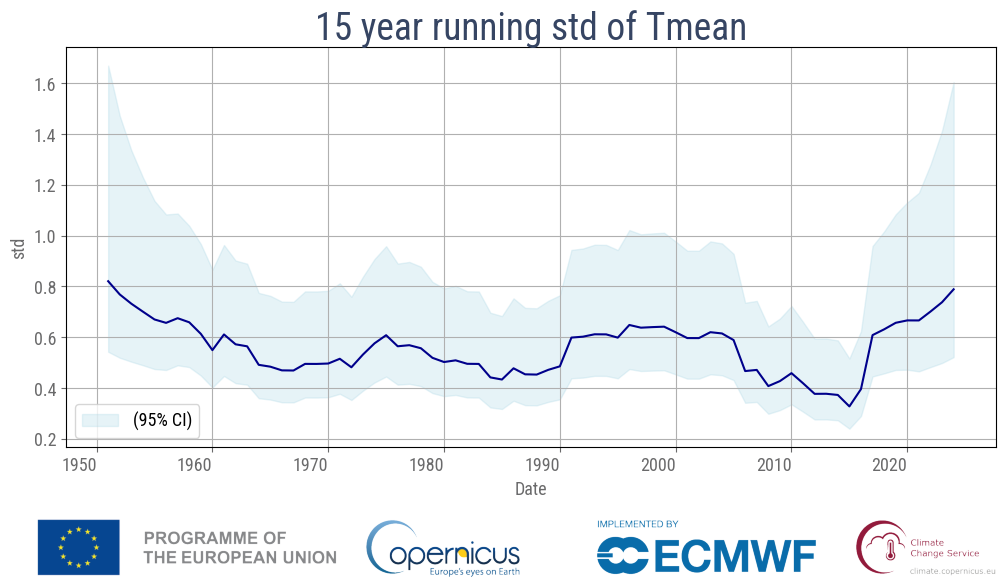

In [12]:
plot_timeseries_test(data=ts_ann_studyregion_15ym, datetime_col="year", value_col=value_col,
               title=f"15 year running {method} of {parameter}", x_label="Date", y_label=method, line_style='solid', ci=True);

## 3.2.d. Decide on which years to use if data is not homogeneous

### <font color='orange'>Specify the preferred time range based on the plot</font>

In [13]:
year_range = (1951, event_year)

### <font color='green'> Slice the annual time series on the given time range </font>

In [14]:
ts_ann_studyregion_subset = subset_gdf(gdf=ts_ann_studyregion, datetime_col="year", date_range=(year_range[0], year_range[1]))
ts_ann_studyregion_subset

,year,3_day_rolling_date,t2m
0,1951,1951-05-11,25.473043
1,1952,1952-03-21,23.542637
2,1953,1953-05-20,25.008805
3,1954,1954-05-01,23.474266
4,1955,1955-05-22,24.964003
...,...,...,...
69,2020,2020-04-23,26.030916
70,2021,2021-04-27,25.478907
71,2022,2022-04-17,26.059287
72,2023,2023-06-14,26.841099


## 3.3 Conclude about the quality of ERA5
(and potentially other datasets) for the specific event definition and implications for the study results and the years to use, write into the output table in Notes & tables and the scientific report Section 2.1.
- a. For the region, check performance of the dataset, conclude on whether the data can be used with limited problems (“satisfactory”) or caution is necessary (“caution”) and conclude on a sentence in the scientific report
    - i. Temperature, include a statement on the performance of ERA5 for temperature based on Lopes et al. (2024) Conclusions from this paper are summarized here (attached to deliverable).
    - ii. Precipitation, include a statement on the performance of ERA5 for precipitation based on Lavers et al. (2022) Conclusions from this paper are summarized here (attached to deliverable).
    - iii. Other variable: if drought, base a general statement on temperature and precipitation, and/or perform literature study on the index and region specifically.
- b. For the use of years, using plots produced in Step 3.2.b visually check whether scale (temperature) or dispersion (precipitation) parameter show a trend and only use the stationary scale/dispersion-fit if the stationarity assumption is not obviously invalid in the sense that the trend is much greater than variability. Otherwise, a non-stationary scale- or
dispersion-parameter would be more appropriate (not part of OAO protocol). Add a sentence on caution on the results should be added to the scientific report Sec. 3.1 - see also Step 3.5b.iv

## 3.4 decide on which covariate to use
(normally this will only be GMST, smoothed with a 4-year running mean to remove the El Nino signal) and make sure the 4-year smoothed ERA5 GMST is updated up to the current month.
- a. C3S defines the 1850–1900 pre‑industrial global mean surface temperature to be 0.88 °C below the 1991–2020 ERA5 global average.

In [11]:
# location of the gmst data
gmst_url = "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv"

method = "mean"



In [20]:
# import gmst data as seen in
# https://github.com/maris-development/c3s-451/blob/development/input-notebooks/notebooks/gmst.ipynb

datetime_col = "valid_time"
gmst_col = "gmst"

# read in the data
gmst = (
    pd.read_csv(
        gmst_url,
        na_values=["****", "***"],
        index_col=0,
        skiprows=1,
        comment="#",
    )
)

# unpivot the df
gmst_monthly = (
    pd.concat([
        pd.DataFrame({
            datetime_col: [datetime(y, i + 1, 1) for y in gmst.index],
            gmst_col: gmst.iloc[:, i].values
        })
        for i in range(12)
    ])
    .sort_values(datetime_col)
    .dropna(subset=[gmst_col])
    .reset_index(drop=True)
)
gmst_monthly

,valid_time,gmst
0,1880-01-01,-0.19
1,1880-02-01,-0.25
2,1880-03-01,-0.09
3,1880-04-01,-0.16
4,1880-05-01,-0.10
...,...,...
1743,2025-04-01,1.23
1744,2025-05-01,1.07
1745,2025-06-01,1.05
1746,2025-07-01,1.01


In [ ]:
# calculate the rolling mean
gmst_monthly_rolled = calculate_rolling_window(gdf=gmst_monthly, value_col=gmst_col, datetime_col=datetime_col,
                                               window=48, min_periods=24, centering=True, method=method)
# select only the specified years
gmst_monthly_rolled = subset_gdf(gdf=gmst_monthly_rolled, datetime_col=datetime_col, year_range=year_range)
gmst_monthly_rolled

,valid_time,gmst
852,1951-01-01,-0.087917
853,1951-02-01,-0.087708
854,1951-03-01,-0.081667
855,1951-04-01,-0.078958
856,1951-05-01,-0.072708
...,...,...
1735,2024-08-01,1.168378
1736,2024-09-01,1.174444
1737,2024-10-01,1.182571
1738,2024-11-01,1.189118


In [31]:
gmst_yearly, rolled_gdf = calculate_yearly_value(gdf=gmst_monthly_rolled, value_col=gmst_col, datetime_col=datetime_col, yearly_value=method)
gmst_yearly

,year,gmst
0,1951,-0.065764
1,1952,-0.038785
2,1953,-0.024358
3,1954,-0.073125
4,1955,-0.106719
...,...,...
69,2020,0.927465
70,2021,0.941441
71,2022,1.003646
72,2023,1.092974


In [32]:
merged_t2m_gmst = pd.merge(ts_ann_studyregion_subset, gmst_yearly, left_on="year", right_on="year", how="inner")

# calculate anomaly relative to event year
ref_val = merged_t2m_gmst.loc[merged_t2m_gmst["year"] == event_year, gmst_col].values[0]

merged_t2m_gmst_anomaly = merged_t2m_gmst.copy()
merged_t2m_gmst_anomaly[gmst_col] = merged_t2m_gmst_anomaly[gmst_col] - ref_val

merged_t2m_gmst_anomaly.to_csv("../data/gmst_t2m.csv", index=False)
# gmst_monthly_rolled

merged_t2m_gmst_anomaly

,year,3_day_rolling_date,t2m,gmst
0,1951,1951-05-11,25.473043,-1.225972
1,1952,1952-03-21,23.542637,-1.198993
2,1953,1953-05-20,25.008805,-1.184566
3,1954,1954-05-01,23.474266,-1.233333
4,1955,1955-05-22,24.964003,-1.266927
...,...,...,...,...
69,2020,2020-04-23,26.030916,-0.232743
70,2021,2021-04-27,25.478907,-0.218767
71,2022,2022-04-17,26.059287,-0.156562
72,2023,2023-06-14,26.841099,-0.067234


## 3.5 Apply statistical method
information for decisions on fit properties:
- a. fit data to statistical model, and check, at least by eye, that this fit agrees with the observed data points. Show this in a figure.
    - i. Gauss - soft extremes with low return periods that are not in the tail. Threshold μ (mu), scale parameter σ (sigma). Usually used for seasonal averages.
    - ii. GEV - largest observation from a large sample: annual/seasonal maximum, block maximum. Location parameter μ, scale parameter σ, shape parameter ξ. Usually used for 1-day to 14-day averages, annual (or seasonal) maximum
    - iii. For in-depth studies potentially use Lognormal, possibly better for precipitation.
- b. shift/scale with GMST or other proxy for anthropogenic forcing
    - i. for temperature extremes the distribution shifts due to global warming without changing the shape (variability: σ, ξ constant).
    - ii. for precipitation (and wind) extremes the distribution scales (variability over mean: dispersion parameter σ/μ and ξ constant).
    - iii. For precipitation with Lognormal use shift
    - iv. Use the visual check of scale or dispersion parameter (done in Step 3.3b): use the stationary scale/dispersion-fit if the stationarity assumption is not obviously invalid. Otherwise using a non-stationary scale- or dispersion-parameter would be more appropriate, and a sentence on caution on the results should be added to the scientific report Section. 3.1
    - v. decide on which covariate to use (normally GMST, smoothed with a 4-year running mean or a similar method to remove the El Nino signal)
    - vi. Include the datapoint of the event under study in the fit

### <font color='orange'>Please specify the following variables<font>

In [33]:
%%R -i event_year -i value_col
dist = "gev"
fit_type = "shift"
covnm = "gmst"
lower = FALSE
cooling_offset = 1.3

In [34]:
%%R -i merged_t2m_gmst_anomaly 

df <- merged_t2m_gmst_anomaly

mdl <- fit_ns(dist = dist, type = fit_type, data = df, varnm = value_col, covnm = covnm, lower = lower, ev_year = event_year)

# the factual climate should have the GMST of the year in which the event occurred
cov_factual <- data.frame(gmst = df$gmst[df$year == event_year])

# the counterfactual climate can represent any alternative climate (WWA always uses a preindustrial climate, 1.3C cooler than the present)
cov_counterfactual <- data.frame(gmst = df$gmst[df$year == event_year] - cooling_offset)

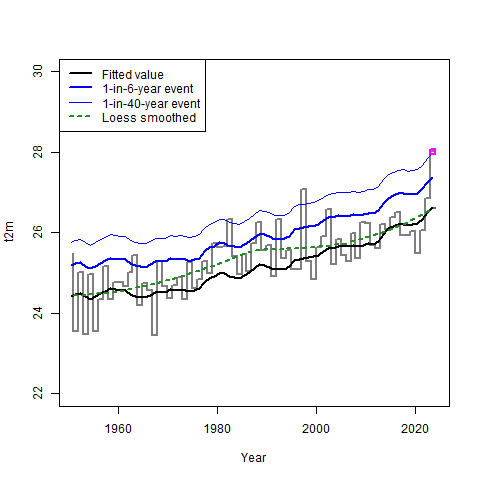

In [39]:
%%R

# what does the fitted trend look like over time?
# `add_loess = T` will add a nonparametric smoother - use this to check whether the fitted model captures the observed trend
plot_trend(mdl, add_loess = T, ylim = c(22,30))

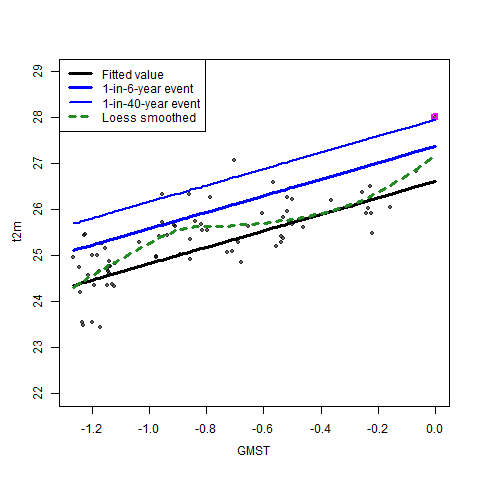

In [41]:
%%R
# what does the fitted trend look like vs GMST?
plot_covtrend(mdl, xcov = covnm, add_loess = T, ylim = c(22,29))

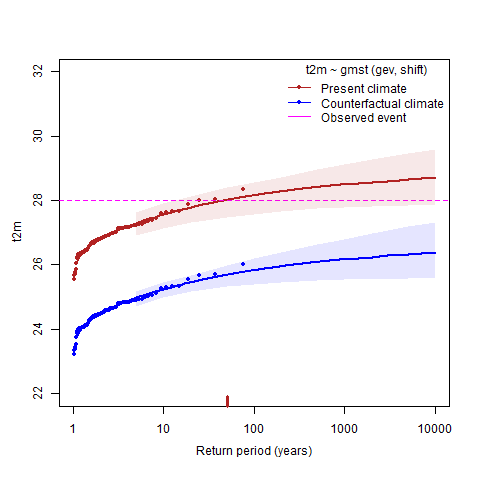

In [44]:
%%R
# How well does the model fit the data?
# the points should be close to the line - if they're not within the shaded region, the model is a poor fit
plot_returnlevels(mdl, cov_f = cov_factual, cov_cf = cov_counterfactual, ylim = c(22,32))

## 3.6 Observed probability and trend detection:
- a. Note down decision on the statistical method (see Step 3.5) in the Notes & Tables document
- b. Note dGMST, i.e. the difference between GMSTevent and GMSTpast, based on the Global Warming Index (https://www.globalwarmingindex.org) in 1 digits, e.g. 1.3 (this is the value in 2025). Check once a year that this value is still valid.
- c. Use all observational/reanalysis datasets that passed the quality checks (years see Step 3.2d). This is likely ERA5 and potentially also a station data time series.
- d. Note down/save variability or variability over mean (σ or σ/μ) and shape parameter ξ (for GEV) of the fit
- e. Note down return period in the current climate Yevent, e.g., 2025, and decide on the single rounded value that will be used for communication purposes and the model analyses – write this in the output table in Notes & Tables (bottom row). Rounding should correspond to the order of magnitude of the bandwidth, e.g., 13.876 (minimum 8.124 to maximum 20.573) should then be 14 (8-21.)
    - i. if necessary, make decision on using e.g. lower bound in case of too extreme return period. Then use this value in models analysis as well.
- f. Note down the threshold value corresponding to the event
- g. Note down probability ratio PR for dGMST, and change in intensity ΔI (absolute value for temperature, % for precipitation)

In [ ]:
%%R
# use the built-in function to bootstrap the model results
boot_res <- boot_ci(mdl, cov_f = cov_factual, cov_cf = cov_counterfactual)

print(boot_res)

# save as a .csv to look at them later
write.csv(boot_res, "../data/res-obs_era5.csv")

                         est         2.5%        97.5%
mu0              25.72105736  24.92596025  26.56959785
sigma0            1.07749551   0.81935940   1.25308535
alpha_gmst        1.94422016   1.03237573   2.80043030
shape            -0.24968175  -0.40057700  -0.09248831
disp              0.04189157   0.03144492   0.04894082
event_magnitude  28.80707795  28.80707795  28.80707795
return_period   153.27276540  20.35494514          Inf
PR                       Inf 282.63533677          Inf
dI_abs            2.52748621   1.63938769   3.67753523
dI_rel            9.61767686   6.03432915  14.63437333
aic             231.06666587 198.89775440 248.10475751
n                74.00000000 500.00000000   0.00000000


In [ ]:
%%R

# comment out the top & bottom lines to see what the figures look like before saving them
png("../data/fig_obs-trend_era5.png", height = 480, width = 480); {
    plot_trend(mdl, add_loess = T, ylim = c(18,33), ylab = "Mean temperature (degC)", lwd = 2)
}; dev.off()

png("../data/fig_obs-gmsttrend_era5.png", height = 480, width = 480); {
    plot_covtrend(mdl, xcov = "gmst", add_loess = T, ylim = c(18,33), ylab = "Mean temperature (degC)", lwd = 2)
}; dev.off()

png("../data/fig_obs-returnlevels_era5.png", height = 480, width = 480); {
    plot_returnlevels(mdl, cov_f = cov_factual, cov_cf = cov_counterfactual, ylim = c(18,33), ylab = "Mean temperature (degC)",
                     legend_labels = c("2025", "Preindustrial"))
}; dev.off()

png 
  2 


In [ ]:
%%R
rp_factual <- return_period(mdl, x = 25, fixed_cov = cov_factual)
rp_counterfactual <- return_period(mdl, x = 25, fixed_cov = cov_counterfactual)

cat("Return period (factual):\n")
print(rp_factual)
cat("\nReturn period (counterfactual):\n")
print(rp_counterfactual)


Return period (factual):
[1] 1.185085

Return period (counterfactual):
[1] 9.285167


In [ ]:
%%R

# try fitting different distributions to compare which actually fits better
mdl_gev <- fit_ns(dist = "gev", type = "shift", data = df, varnm = value_col, covnm = "gmst", lower = F)
mdl_norm <- fit_ns(dist = "norm", type = "shift", data = df, varnm = value_col, covnm = "gmst", lower = F)

# use AIC to identify the model that fits better (lower score is better)
cat("AIC (GEV):", aic(mdl_gev), "\n")
cat("AIC (Normal):", aic(mdl_norm), "\n")

AIC (GEV): 231.0667 
AIC (Normal): 229.3222 


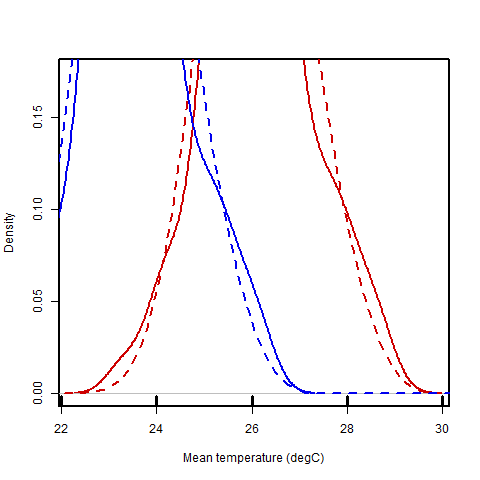

In [ ]:
%%R

# the 'rwwa' package has a built-in function to transform all points into the factual or counterfactual climate
y_factual <- stransform(mdl, fixed_cov = cov_factual)
y_counterfactual <- stransform(mdl, fixed_cov = cov_counterfactual)

# it can also extract the model parameters for a fixed value of the covariates
pars_factual <- ns_pars(mdl, fixed_cov = cov_factual)
pars_counterfactual <- ns_pars(mdl, fixed_cov = cov_counterfactual)

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# we can therefore plot the density of the temperatures as they would have been in today's climate, or in the counterfactual climate
par(lwd = 2)
plot(density(y_factual), col = "red3", ylim = c(0, 0.175), main = "", 
     xlab = "Mean temperature (degC)")

# factual model fit (dashed line)
x <- seq(15, 35, 0.1)
lines(x, devd(x, loc = pars_factual$loc, scale = pars_factual$scale, shape = pars_factual$shape),
      type = "l", col = "red3", lty = 2)

# counterfactual density and fit
lines(density(y_counterfactual), col = "blue2")
lines(x, devd(x, loc = pars_counterfactual$loc, scale = pars_counterfactual$scale, shape = pars_counterfactual$shape),
      type = "l", col = "blue2", lty = 2)

# add ticks for observed temperatures
rug(df$tmax, lwd = 3)

## 3.7 Literature review specific on the investigation of other possible climatic drivers of the event (modes of natural variability) for regions where they are important.
Steps a.i, b, c and d are essential, but if time allows it is useful to additionally do some of the optional steps.
- a. First find out what drivers influence (extremes in) the event type at the event location and its variability and trend, for example, using the following sources (see also Sec. 6a. Literature research)
    - i. Visually inspect teleconnection maps for average response of T/precip per month during years of high index https://confluence.ecmwf.int/display/COPSRV/ENSO+impacts+on+Europe and describe average impact over the region assessed if it is an ENSO year (see next step). In the maps “Global effects - temperature and precipitation” use
        - 7.a.i.1. Month of interest
        - 7.a.i.2. Variable of interest (top figures: temperature, bottom figures: precipitation)
        - 7.a.i.3. El Nino (figures left) or La Nina (figures right)
    - ii. OPTIONAL: Via IPCC AI chat https://www.climateqa.com/ e.g. by asking the question “what climate drivers influence the extremes, variability and trend of rainfall in Somalia” and, if El Niño is the answer, “what is the influence of El Niño on rainfall in Somalia?”. Any content derived from AI must be quality assured before inclusion in output.
    - iii. OPTIONAL: Search generally or in scholar.google.com for literature. ClimateQA can be used to summarise papers, in conjunction with careful proof reading of the output.
    - iv. OPTIONAL: Potentially ask this to the local experts.
- b. Assess what the current status of those drivers is on the current event. If e.g. ENSO is a driver, but ENSO is currently in a neutral state then, whilst ENSO influences the variability of the time series, it did not play a prominent role in the magnitude of the current event. Check the following and download the relevant graphics for the current status of ENSO and IOD.
    - i. ENSO
    - ii. IOD
- c. Decide whether an in-depth study should be considered and communicate this with the rest of the Team.
    - i. Investigate influence of modes of natural variability e.g. ENSO as 2nd covariate. The procedures in python notebook X can be followed.
- d. Summarise findings and decisions in scientific report Section 3.3 and summarise the findings in one sentence for the fact sheet.